##Problem 1

In [1]:
# current working directory
import os
print(os.getcwd())
print()

C:\Users\Kawsar Ali\OneDrive\Desktop\4th year 1st Semester\4104(Siddik sir)\Lab\Pythone



Basic EDA

Load packeges and data

i) Age distribution — Normal or Skewed

In [28]:
#install necessary packeges
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
# read data
df = pd.read_csv("lung_disease.csv")
df.head()

,ID,Smoking,Age,Income,Pollution,LungDisease
0,1,Yes,36,Low,High,Yes
1,2,No,28,Low,Low,No
2,3,No,52,Medium,High,No
3,4,No,39,High,High,No
4,5,Yes,32,Low,Low,Yes


Basic EDA
(i)Age distribution — Normal or Skewed

count    500.000000
mean      43.904000
std       14.604841
min       20.000000
25%       30.750000
50%       45.000000
75%       56.000000
max       69.000000
Name: Age, dtype: float64


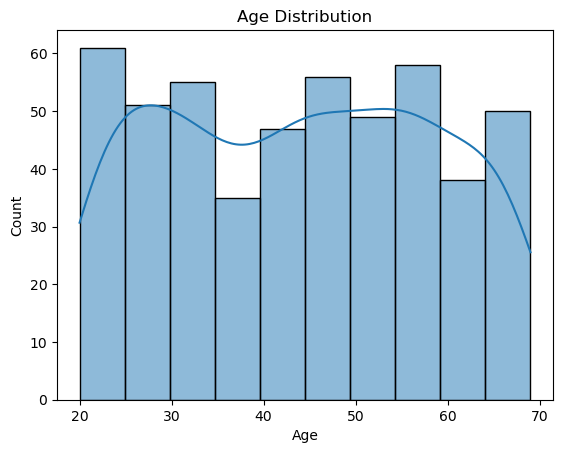

Skewness: 0.012141455267137275


In [4]:
#Age distribution
print(df['Age'].describe())

#plot
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Skewness check
print("Skewness:", df['Age'].skew())

(ii) Smokers vs Non-smokers proportion

In [29]:
smoke_prop = df['Smoking'].value_counts(normalize=True) * 100
print(smoke_prop)

Smoking
No     58.6
Yes    41.4
Name: proportion, dtype: float64


Encode data

In [32]:
import pandas as pd
df_encoded = df.copy()
df_encoded['Smoking'] = df_encoded['Smoking'].map({'Yes': 1, 'No': 0})
df_encoded['LungDisease'] = df_encoded['LungDisease'].map({'Yes': 1, 'No': 0})
df_encoded['Income'] = df_encoded['Income'].map({'Low': 1, 'Medium': 2, 'High': 3})
df_encoded['Pollution'] = df_encoded['Pollution'].map({'Low': 0, 'High': 1})

iii) Highest frequency income group

In [7]:
# income group counts
print(df_encoded['Income'].value_counts())

Income
1    204
2    197
3     99
Name: count, dtype: int64


iv) Percentage exposed to high pollution

In [8]:
# Percentage exposed to high pollution
pollution_pct = df_encoded['Pollution'].mean() * 100
print(f"High pollution exposure: {pollution_pct:.2f}%")

High pollution exposure: 70.40%


v) Overall prevalence of lung disease

In [9]:
disease_pct = (df['LungDisease'] == 'Yes').mean() * 100
print(f"Lung disease prevalence: {disease_pct:.2f}%")

Lung disease prevalence: 52.80%


🔹 Association & Crosstab


i) Association between Smoking and Lung Disease

In [10]:
from scipy.stats import chi2_contingency, fisher_exact
# Create contingency table
cont_table = pd.crosstab(df['Smoking'], df['LungDisease'])
print(cont_table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [11]:
chi2, p, dof, expected = stats.chi2_contingency(cont_table)
print(f"Chi-square = {chi2:.2f}, p-value = {p:.4f}")

# Fisher's Exact (only for 2x2)
if cont_table.shape == (2,2):
    oddsratio, p_fisher = fisher_exact(cont_table)
    print("Fisher p-value:", p_fisher)

Chi-square = 67.59, p-value = 0.0000
Fisher p-value: 5.128610707567623e-17


ii) Interpret contingency table

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


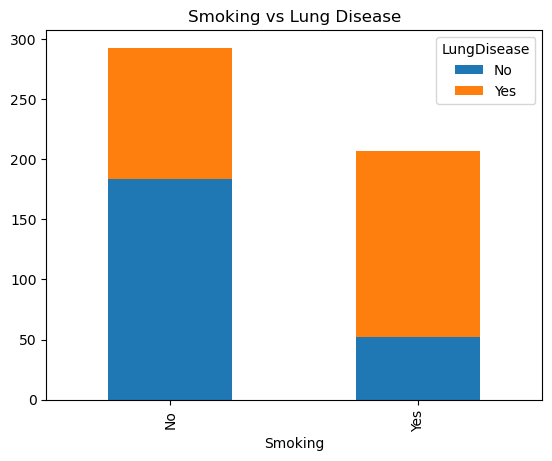

In [12]:
print(cont_table)
cont_table.plot(kind='bar', stacked=True)
plt.title("Smoking vs Lung Disease")
plt.show()

🔹 Does Pollution Level Affect Lung Disease?

i) Compare lung disease prevalence across Income groups

LungDisease         No        Yes
Income                           
High         51.515152  48.484848
Low          44.117647  55.882353
Medium       48.223350  51.776650


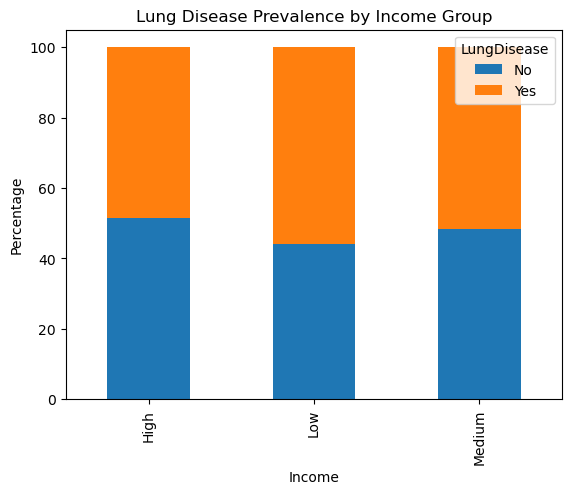

In [13]:
income_disease = pd.crosstab(df['Income'], df['LungDisease'], normalize='index') * 100
print(income_disease)
income_disease.plot(kind='bar', stacked=True)
plt.title("Lung Disease Prevalence by Income Group")
plt.ylabel("Percentage")
plt.show()


i) Which factor has the strongest relationship with lung disease

In [14]:
from scipy.stats import chi2_contingency

factors = ['Smoking', 'Pollution', 'Income']
for f in factors:
    table = pd.crosstab(df[f], df['LungDisease'])
    chi2, p, dof, exp = chi2_contingency(cont_table)
    print(f"{f}: p-value = {p}")


Smoking: p-value = 2.0085094601569646e-16
Pollution: p-value = 2.0085094601569646e-16
Income: p-value = 2.0085094601569646e-16


In [17]:
from scipy.stats import chi2_contingency
import pandas as pd

factors = ['Smoking', 'Pollution', 'Income']

for f in factors:
    table = pd.crosstab(df[f], df['LungDisease'])
    chi2, p, dof, exp = chi2_contingency(table)
    
    if p < 0.05:
        result = "Significant (real relationship exists)"
    else:
        result = "Not significant (no relationship)"
    
    print(f"{f}: p-value = {p:.4e} → {result}")

Smoking: p-value = 2.0085e-16 → Significant (real relationship exists)
Pollution: p-value = 5.9757e-09 → Significant (real relationship exists)
Income: p-value = 4.4929e-01 → Not significant (no relationship)


🔹 Statistical Testing

i) Chi-square test for Smoking vs lung disease and Pollution vs lung disease

In [21]:
#chi_sq on Smoking vs lung disease 
table_smoke = pd.crosstab(df['Smoking'], df['LungDisease'])
chi2_smoke, p_smoke, _, _ = stats.chi2_contingency(table_smoke)
print(f"Smoking vs Lung Disease: p = {p_smoke}")

#Chi_sq on Pollution vs lung disease
chi2_poll, p_poll, _, _ = stats.chi2_contingency(table_poll)
table_poll = pd.crosstab(df['Pollution'], df['LungDisease'])
print(f"Pollution vs Lung Disease: p = {p_poll}")

Smoking vs Lung Disease: p = 2.0085094601569646e-16
Pollution vs Lung Disease: p = 5.975692575712951e-09


iii) Calculate and interpret Odds Ratio for Smoking and Lung Disease

In [24]:
# fnding odds ratio
table = pd.crosstab(df['Smoking'], df['LungDisease'])
odds_ratio = (table.iloc[1,1] / table.iloc[1,0]) / (table.iloc[0,1] / table.iloc[0,0])
print(f"Odds Ratio: {odds_ratio:.2f}")


Odds Ratio: 5.03


🔹 Correlation & Interpretation

i) Correlation between Smoking, Age, and Lung Disease

In [25]:
corr_smoke = df['Smoking'].astype('category').cat.codes.corr(df['LungDisease'].astype('category').cat.codes)
corr_age = df['Age'].corr(df['LungDisease'].astype('category').cat.codes)
print(f"Smoking-Lung Disease correlation: {corr_smoke:.2f}")
print(f"Age-Lung Disease correlation: {corr_age:.2f}")


Smoking-Lung Disease correlation: 0.37
Age-Lung Disease correlation: 0.25


🔹 Logistic Regression

i) Fit a logistic regression model

In [42]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Logistic regression model
model = smf.logit('LungDisease ~ Smoking + Age + Pollution + Income', data=df_encoded).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            LungDisease   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2005
Time:                        01:51:16   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 5.546e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8373      0.461     -6.153      0.000      -3.741      -1.934
Smoking        1.7021      0.

ii) statistically significant variable

In [37]:
print(model.pvalues)

Intercept    7.589721e-10
Smoking      5.736491e-15
Age          4.883161e-08
Pollution    3.101963e-08
Income       1.138236e-01
dtype: float64


🔹 Advanced Modeling

i) Add an interaction term (Smoking × Pollution)

In [39]:
model_interact = smf.logit('LungDisease ~ Smoking * Pollution + Age + Income', data=df_encoded).fit()
print(model_interact.summary())

Optimization terminated successfully.
         Current function value: 0.552178
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            LungDisease   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2016
Time:                        01:16:34   Log-Likelihood:                -276.09
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 2.399e-28
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.9471      0.483     -6.101      0.000      -3.894      -2.000
Smoking 

🔹Model Evaluation

i) Compute the ROC curve and AUC

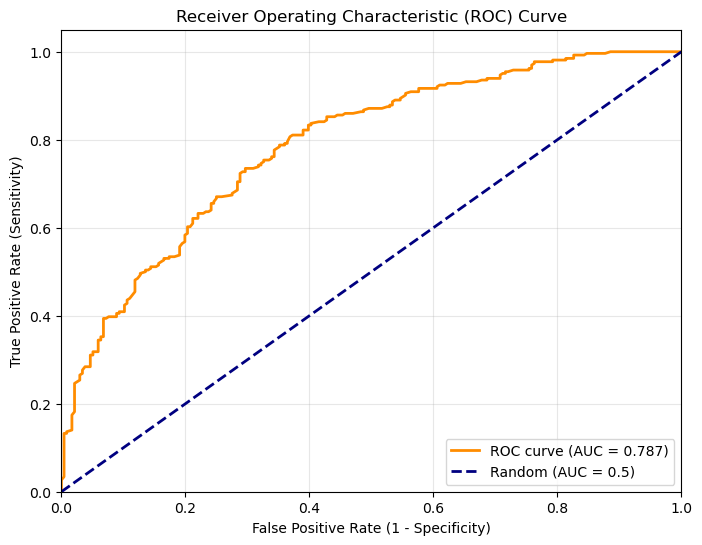

AUC: 0.787


In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_pred_prob = model.predict(df_encoded)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(df_encoded['LungDisease'], y_pred_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f'AUC: {roc_auc:.3f}')

iii) What is the confusion matrix?

In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['LungDisease'] = le.fit_transform(df['LungDisease']) 


# Binary prediction (threshold = 0.5)
y_pred_class = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(df['LungDisease'], y_pred_class)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(df['LungDisease'], y_pred_class))


Confusion Matrix:
 [[156  80]
 [ 63 201]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.66      0.69       236
           1       0.72      0.76      0.74       264

    accuracy                           0.71       500
   macro avg       0.71      0.71      0.71       500
weighted avg       0.71      0.71      0.71       500

